# TP4 - La fonction de Rosenbrock

In [ ]:
from typing import List

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter

# if matplotlib version is lower than 3.2.0, the following line is necessary.
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
def rosenbrock(X,a):
    res=((1-X[0])**2 + a*a* (X[0]-X[1]**2)**2)
    return res

## Partie 1 -  Analyse graphique

### Question 1

On définit `graph_Rosenbrock(a, X, Y)` qui affiche la surface 3D de $f(X,Y) = (1-X)^2 + a^2(X-Y^2)^2$ via `plot_surface`. On teste avec $a=1$ sur $[-2,2]^2$.

In [ ]:
def graph_Rosenbrock(a,x,y):
    X, Y = np.meshgrid(x, y)

    ft_rosenbrock = rosenbrock([X,Y],a)

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(X, Y, ft_rosenbrock, cmap='viridis')

    ax.set_title("Surface 3D avec meshgrid")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("f(X,Y)")

    plt.show()
    return

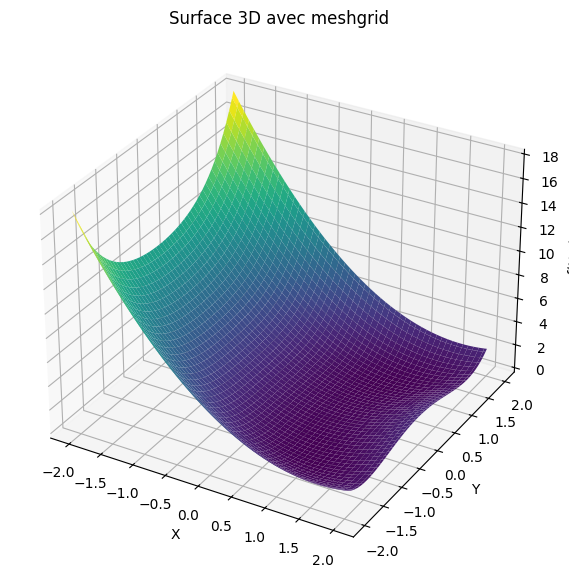

In [ ]:
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
a = 0.5
graph_Rosenbrock(a,x,y)

### Question 2

On représente $f$ avec $a=0.2$. La vallée est beaucoup moins prononcée : le terme $a^2(x-y^2)^2$ pèse moins, la surface est plus aplatie.

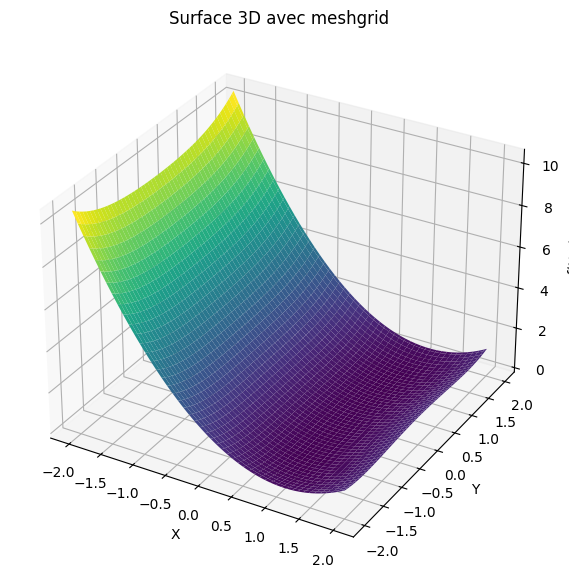

In [ ]:
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
a = 0.2
graph_Rosenbrock(a,x,y)

### Question 3

In [ ]:
def graph_Rosenbrock_contour(a, X, Y, nb_lignes):
    X, Y = np.meshgrid(X, Y)
    Z = rosenbrock([X, Y], a)
    plt.figure(figsize=(10, 7))
    plt.contour(X, Y, Z, nb_lignes, cmap=cm.jet)
    plt.colorbar(label='f(X,Y)')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'Lignes de niveaux de Rosenbrock (a={a}, {nb_lignes} lignes)')
    plt.show()

### Question 4

En observant les lignes de niveaux, on repère trois points critiques pour $a=1$ :
- $a_1 = (1, 1)$ : minimum global, $f(a_1) = 0$
- $a_2 = (1, -1)$ : minimum global, $f(a_2) = 0$ (symétrie $y \to -y$)
- $a_3 = (1/(1+a^2), 0) = (0.5, 0)$ : point selle, $f(a_3) = 0.25$

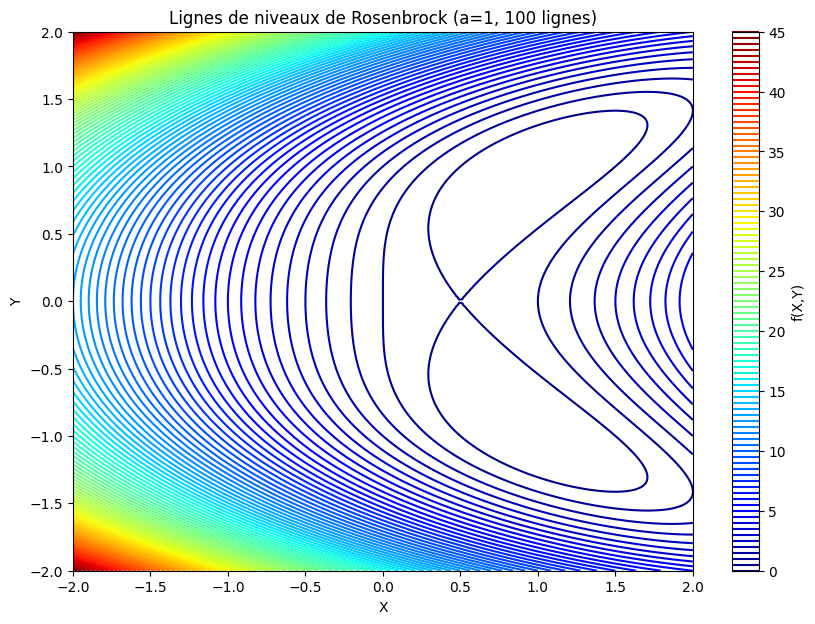

In [ ]:
X = np.linspace(-2, 2, 200)
Y = np.linspace(-2, 2, 200)
graph_Rosenbrock_contour(1, X, Y, 100)

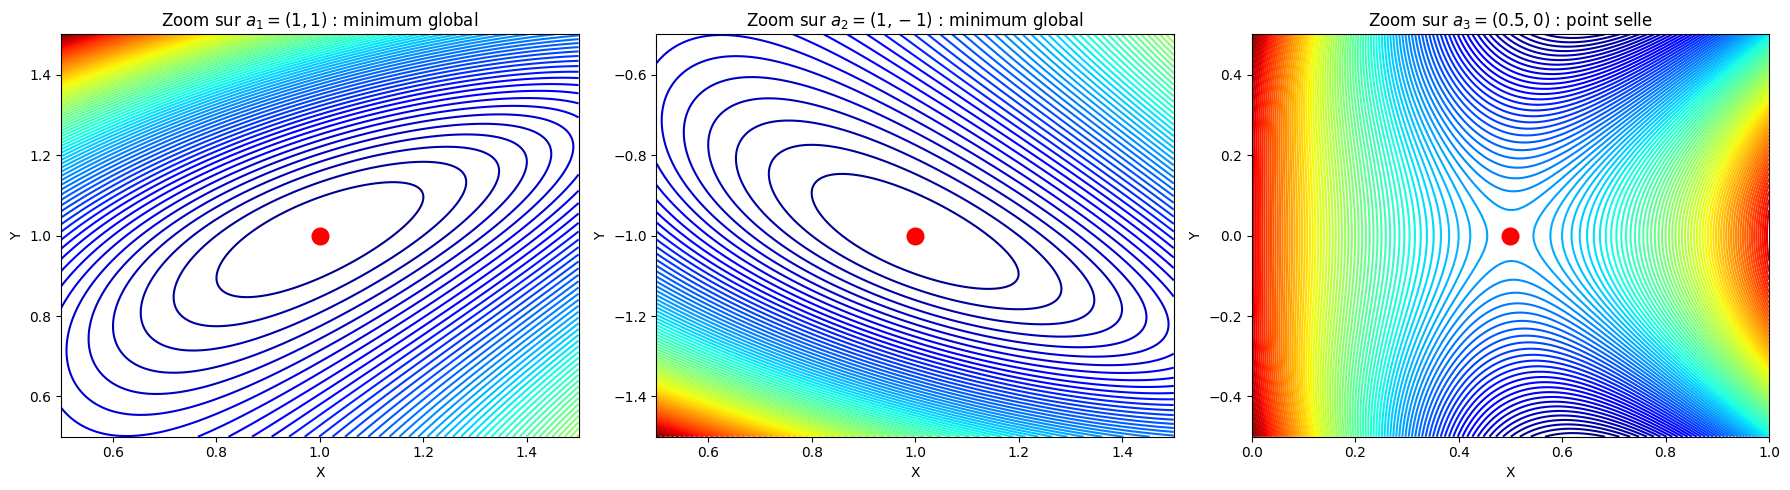

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Zoom sur a1 = (1, 1)
X1 = np.linspace(0.5, 1.5, 200)
Y1 = np.linspace(0.5, 1.5, 200)
Xm1, Ym1 = np.meshgrid(X1, Y1)
Zm1 = rosenbrock([Xm1, Ym1], 1)
axes[0].contour(Xm1, Ym1, Zm1, 100, cmap=cm.jet)
axes[0].plot(1, 1, 'ro', markersize=12)
axes[0].set_title('Zoom sur $a_1 = (1, 1)$ : minimum global')
axes[0].set_xlabel('X'); axes[0].set_ylabel('Y')

# Zoom sur a2 = (1, -1)
X2 = np.linspace(0.5, 1.5, 200)
Y2 = np.linspace(-1.5, -0.5, 200)
Xm2, Ym2 = np.meshgrid(X2, Y2)
Zm2 = rosenbrock([Xm2, Ym2], 1)
axes[1].contour(Xm2, Ym2, Zm2, 100, cmap=cm.jet)
axes[1].plot(1, -1, 'ro', markersize=12)
axes[1].set_title('Zoom sur $a_2 = (1, -1)$ : minimum global')
axes[1].set_xlabel('X'); axes[1].set_ylabel('Y')

# Zoom sur a3 = (0.5, 0)
X3 = np.linspace(0, 1, 200)
Y3 = np.linspace(-0.5, 0.5, 200)
Xm3, Ym3 = np.meshgrid(X3, Y3)
Zm3 = rosenbrock([Xm3, Ym3], 1)
axes[2].contour(Xm3, Ym3, Zm3, 100, cmap=cm.jet)
axes[2].plot(0.5, 0, 'ro', markersize=12)
axes[2].set_title('Zoom sur $a_3 = (0.5, 0)$ : point selle')
axes[2].set_xlabel('X'); axes[2].set_ylabel('Y')

plt.tight_layout()
plt.show()

## Partie 2 : Analyse symbolique


In [ ]:
import sympy as sym

### Question 1

On définit les variables symboliques $x$, $y$, $a$ et l'expression symbolique de $f(x,y)$.

In [ ]:
x,y,a = sym.symbols('x y a')
sym_Rosenbrock = ((1-x)**2 + a*a* (x-y**2)**2)
sym_Rosenbrock

a**2*(x - y**2)**2 + (1 - x)**2

### Question 2

On calcule le gradient $\nabla f(x,y)$ à l'aide de `sym.diff` et on le met sous forme matricielle avec `sym.Matrix`.

In [ ]:
sym_gradient = sym.Matrix([sym.diff(sym_Rosenbrock,x),sym.diff(sym_Rosenbrock,y)])
sym_gradient

Matrix([
[a**2*(2*x - 2*y**2) + 2*x - 2],
[         -4*a**2*y*(x - y**2)]])

### Question 3

On résout $\nabla f(x,y) = 0$ avec `sym.solve` pour retrouver les trois points critiques $a_1, a_2, a_3$.

In [ ]:
pts_critiques = sym.solve(sym_gradient)
pts_critiques

[{a: 0, x: 1}, {x: 1, y: -1}, {x: 1, y: 1}]

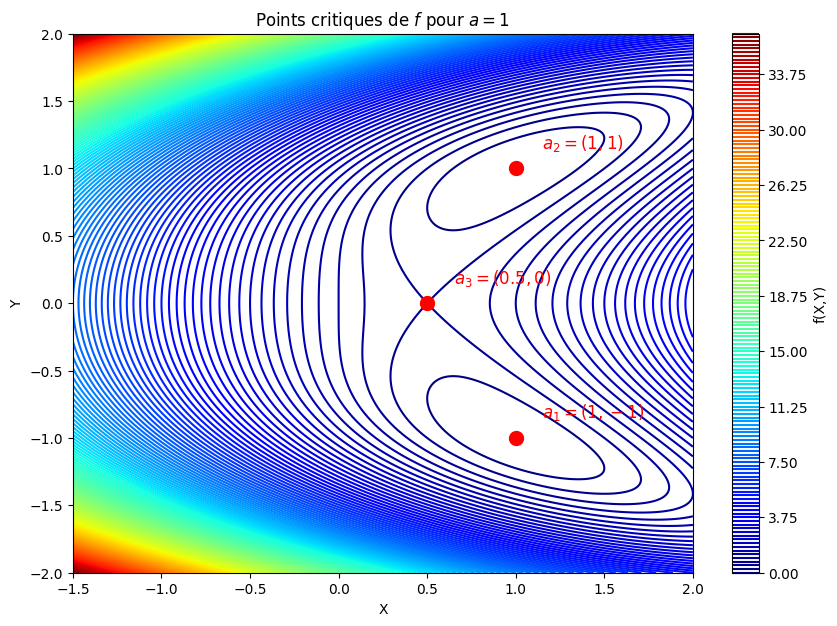

In [ ]:
X_plot = np.linspace(-1.5, 2, 300)
Y_plot = np.linspace(-2, 2, 300)
Xm, Ym = np.meshgrid(X_plot, Y_plot)
Zm = rosenbrock([Xm, Ym], 1)

plt.figure(figsize=(10, 7))
plt.contour(Xm, Ym, Zm, 150, cmap=cm.jet)
plt.colorbar(label='f(X,Y)')

pts_num = [(1, -1), (1, 1), (0.5, 0)]
labels = ['$a_1 = (1,-1)$', '$a_2 = (1,1)$', '$a_3 = (0.5, 0)$']
for pt, lab in zip(pts_num, labels):
    plt.plot(pt[0], pt[1], 'ro', markersize=10)
    plt.annotate(lab, xy=pt, xytext=(pt[0]+0.15, pt[1]+0.15), fontsize=12, color='red')

plt.title('Points critiques de $f$ pour $a=1$')
plt.xlabel('X'); plt.ylabel('Y')
plt.show()

### Question 4

On calcule la matrice hessienne $\text{Hess}_f(x,y)$ en utilisant la méthode `jacobian` sur le gradient.

In [ ]:
sym_Hess = sym_gradient.jacobian([x,y])
sym_Hess

Matrix([
[2*a**2 + 2,                       -4*a**2*y],
[ -4*a**2*y, 8*a**2*y**2 - 4*a**2*(x - y**2)]])

### Question 5

In [ ]:
keys0 = list(pts_critiques[0].keys())
sym_Hess_a1 = sym_Hess.subs(keys0[0], pts_critiques[0][keys0[0]])
sym_Hess_a1 = sym_Hess_a1.subs(keys0[1], pts_critiques[0][keys0[1]])

keys1 = list(pts_critiques[1].keys())
sym_Hess_a2 = sym_Hess.subs(keys1[0], pts_critiques[1][keys1[0]])
sym_Hess_a2 = sym_Hess_a2.subs(keys1[1], pts_critiques[1][keys1[1]])

keys2 = list(pts_critiques[2].keys())
sym_Hess_a3 = sym_Hess.subs(keys2[0], pts_critiques[2][keys2[0]])
sym_Hess_a3 = sym_Hess_a3.subs(keys2[1], pts_critiques[2][keys2[1]])

sym_Hess_a1

Matrix([
[2, 0],
[0, 0]])

In [ ]:
sym_Hess_a2

Matrix([
[2*a**2 + 2, 4*a**2],
[    4*a**2, 8*a**2]])

In [ ]:
sym_Hess_a3

Matrix([
[2*a**2 + 2, -4*a**2],
[   -4*a**2,  8*a**2]])

### Question 6

On détermine les valeurs propres de chaque $\text{Hess}_f(a_i)$ avec `eigenvals`.

In [ ]:
sym_Hess_a1.eigenvals()

{2: 1, 0: 1}

In [ ]:
sym_Hess_a2.eigenvals()

{5*a**2 - sqrt((5*a**2 - 4*a + 1)*(5*a**2 + 4*a + 1)) + 1: 1,
 5*a**2 + sqrt((5*a**2 - 4*a + 1)*(5*a**2 + 4*a + 1)) + 1: 1}

In [ ]:
sym_Hess_a3.eigenvals()

{5*a**2 - sqrt((5*a**2 - 4*a + 1)*(5*a**2 + 4*a + 1)) + 1: 1,
 5*a**2 + sqrt((5*a**2 - 4*a + 1)*(5*a**2 + 4*a + 1)) + 1: 1}

### Question 7

In [ ]:
sym_Hess = []
sym_Hess.append(sym_Hess_a1)
sym_Hess.append(sym_Hess_a2)
sym_Hess.append(sym_Hess_a3)
for i, hi in enumerate(sym_Hess):
    vp = list(hi.eigenvals().keys())
    vp_num = [v.subs(a, 1) for v in vp]
    if all(v > 0 for v in vp_num):
        nature = 'minimum local'
    elif all(v < 0 for v in vp_num):
        nature = 'maximum local'
    else:
        nature = 'point selle'
    print(f'a{i+1} = {pts_critiques[i]} : {nature} (valeurs propres pour a=1 : {[float(v) for v in vp_num]})')

a1 = {a: 0, x: 1} : point selle (valeurs propres pour a=1 : [2.0, 0.0])
a2 = {x: 1, y: -1} : minimum local (valeurs propres pour a=1 : [1.5278640450004206, 10.47213595499958])
a3 = {x: 1, y: 1} : minimum local (valeurs propres pour a=1 : [1.5278640450004206, 10.47213595499958])


On retrouve bien les résultats de la préparation :
- $a_1 = (1,1)$ et $a_2 = (1,-1)$ sont des **minimums globaux** car les deux valeurs propres sont strictement positives (la fonction est symétrique en $y \to -y$).
- $a_3 = (1/(1+a^2), 0)$ est un **point selle** car les valeurs propres sont de signes opposés.

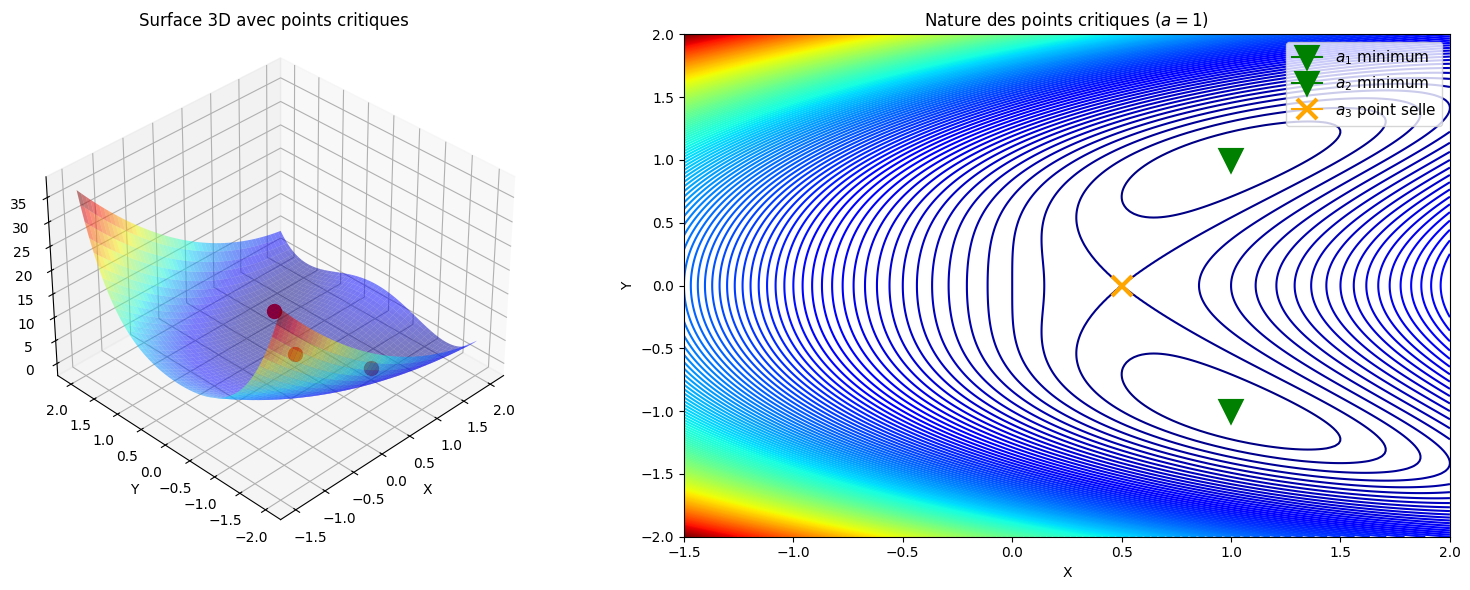

In [ ]:
fig = plt.figure(figsize=(16, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
X_p = np.linspace(-1.5, 2, 200)
Y_p = np.linspace(-2, 2, 200)
Xm, Ym = np.meshgrid(X_p, Y_p)
Zm = rosenbrock([Xm, Ym], 1)
ax1.plot_surface(Xm, Ym, Zm, cmap=cm.jet, alpha=0.5, edgecolor='none')
pts_3d = [(1, 1, 0), (1, -1, 0), (0.5, 0, 0.25)]
for pt in pts_3d:
    ax1.scatter(*pt, color='red', s=100, zorder=5)
ax1.set_title('Surface 3D avec points critiques')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('f')
ax1.view_init(35, 225)

ax2 = fig.add_subplot(1, 2, 2)
ax2.contour(Xm, Ym, Zm, 150, cmap=cm.jet)
colors = ['green', 'green', 'orange']
markers = ['v', 'v', 'x']
noms2 = ['$a_1$ minimum', '$a_2$ minimum', '$a_3$ point selle']
for pt, c, m, nom in zip(pts_3d, colors, markers, noms2):
    ax2.plot(pt[0], pt[1], marker=m, color=c, markersize=14, markeredgewidth=3, label=nom)
ax2.legend(fontsize=11)
ax2.set_title('Nature des points critiques ($a=1$)')
ax2.set_xlabel('X'); ax2.set_ylabel('Y')

plt.tight_layout()
plt.show()

## Partie 3 : Analyse numérique

### Question 1

On écrit `rosenbrock_grad(X)` qui calcule le gradient de $f$ pour $a=1$ : $\nabla f(x,y) = \begin{pmatrix} -2(1-x) + 2(x-y^2) \\ -4y(x-y^2) \end{pmatrix}$

In [ ]:
def rosenbrock_grad(X):
    dfdx = -2*(1 - X[0]) + 2*(X[0] - X[1]**2)
    dfdy = -4*X[1]*(X[0] - X[1]**2)
    return np.array([dfdx, dfdy])

In [ ]:
print('Gradient en (0.1, 0.9) :', rosenbrock_grad([0.1, 0.9]))
print('Gradient en (1, 1) :', rosenbrock_grad([1, 1]))

Gradient en (0.1, 0.9) : [-3.22   2.556]
Gradient en (1, 1) : [0 0]


### Question 2

[ 3.22  -2.556]


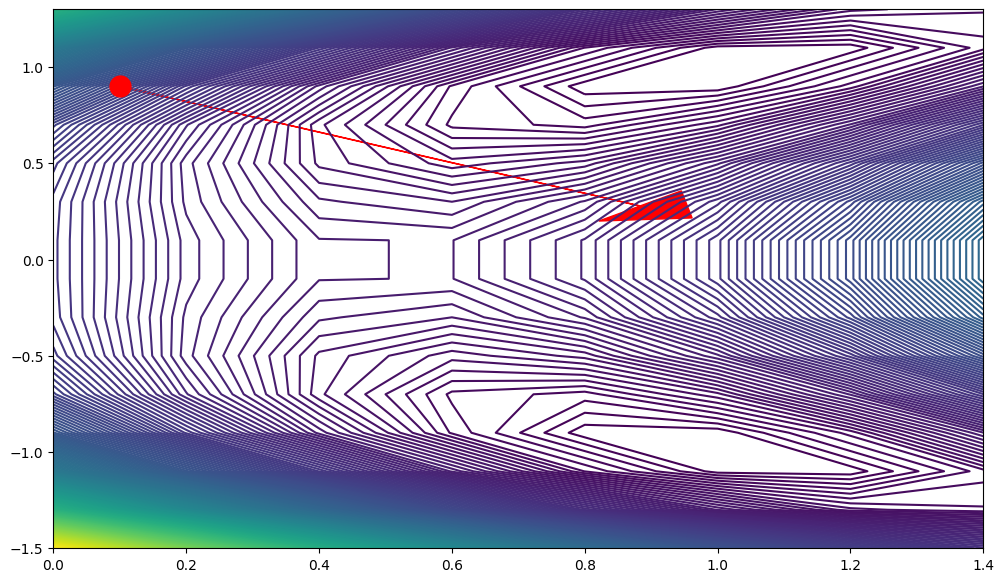

In [ ]:
X = np.arange(0, 1.5, 0.2)
Y = np.arange(-1.5,1.5, 0.2)
X, Y = np.meshgrid(X, Y)
Z = rosenbrock([X, Y],1)

x_init = [0.1, 0.9]

fx = rosenbrock(x_init,1);
gx = rosenbrock_grad(x_init);
s = -gx;
print(s)

ns = np.sqrt(s[0]**2+s[1]**2)
arrowxlen, arrowylen = s[0]/ns,s[1]/ns

plt.figure(figsize=(12, 7))
plt.contour(X,Y,Z,200)
plt.plot([x_init[0]],[x_init[1]],marker='o',markersize=15, color ='r')
plt.arrow(x_init[0],x_init[1], arrowxlen, arrowylen, head_width=0.2, head_length=0.1, fc='r', ec='r')
plt.show()

La flèche rouge représente la direction de l'opposé du gradient $-\nabla f(x_0)$ au point initial $x_0 = (0.1, 0.9)$, c'est-à-dire la **direction de plus forte descente** de $f$ en ce point.

La longueur de la flèche est **normalisée** (divisée par $\|\nabla f(x_0)\|$) : elle vaut donc 1 et n'indique que la **direction**, pas la taille du déplacement réel (qui dépend du pas $\alpha$).

### Question 3

In [ ]:
def graph_Rosenbrock_contour(a, X, Y, nb_lignes):
    X, Y = np.meshgrid(X, Y)
    Z = rosenbrock([X, Y], a)
    plt.figure(figsize=(10, 7))
    plt.contour(X, Y, Z, nb_lignes, cmap=cm.jet)
    plt.colorbar(label='f(X,Y)')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'Lignes de niveaux de Rosenbrock (a={a}, {nb_lignes} lignes)')
    plt.show()

### Question 4

In [ ]:
def gradient_descent(J_grad, x_init, alpha, max_iterations, epsilon=1e-10):
    x = np.array(x_init, dtype=float)
    iter_x = [x[0]]
    iter_y = [x[1]]
    iter_count = 0
    for i in range(max_iterations):
        grad = J_grad(x)
        if np.linalg.norm(grad) < epsilon:
            break
        x = x - alpha * grad
        iter_x.append(x[0])
        iter_y.append(x[1])
        iter_count += 1
    return x, np.array(iter_x), np.array(iter_y), iter_count

### Question 5


Teste de la descente de gradient avec différentes valeurs de `alpha` et `x_init`. la solution converge bien vers $(1,1)$.

In [ ]:
x_init = np.array([0.1, 0.9])
alpha = 0.001
max_iterations = 10000
x, iter_x, iter_y, iter_count = gradient_descent(rosenbrock_grad, x_init, alpha, max_iterations)
print(f'alpha={alpha}, x_init={[0.1,0.9]}')
print(f'  Solution : {x}, iterations : {iter_count}')

alpha=0.001, x_init=[0.1, 0.9]
  Solution : [0.99999982 0.99999989], iterations : 10000


In [ ]:
x_init = np.array([0.5, -0.5])
alpha = 0.001
x2, _, _, ic2 = gradient_descent(rosenbrock_grad, x_init, alpha, 10000)
print(f'alpha={alpha}, x_init={[0.5,-0.5]}')
print(f'  Solution : {x2}, iterations : {ic2}')

alpha=0.001, x_init=[0.5, -0.5]
  Solution : [ 0.99999981 -0.99999989], iterations : 10000


In [ ]:
x_init = np.array([0.1, 0.9])
alpha = 0.01
x3, _, _, ic3 = gradient_descent(rosenbrock_grad, x_init, alpha, 10000)
print(f'alpha={alpha}, x_init={[0.1,0.9]}')
print(f'  Solution : {x3}, iterations : {ic3}')
print()
print('La solution numérique converge vers (1,1), le minimum global trouvé en Partie 2.')

alpha=0.01, x_init=[0.1, 0.9]
  Solution : [1. 1.], iterations : 1519

La solution numérique converge vers (1,1), le minimum global trouvé en Partie 2.


### Question 6

In [ ]:
def plot_trace_GD(iter_x, iter_y):

    # Plotting the Rosenbrock function and the Gradient Descent iteration steps
    X = np.linspace(0,   1.5, 20);
    Y = np.linspace(-1.5,1.5, 40);
    X, Y = np.meshgrid(X, Y);
    Z = rosenbrock([X, Y],1);
    #Angles needed for quiver plot
    anglesx = iter_x[1:] - iter_x[:-1]
    anglesy = iter_y[1:] - iter_y[:-1]
    fig = plt.figure(figsize = (16,8))
    #Surface plot
    ax = fig.add_subplot(1, 2, 1, projection='3d')
    ax.plot_surface(X,Y,Z,rstride = 5, cstride = 5, cmap = 'jet', alpha = .4, edgecolor = 'none' )
    ax.plot(iter_x,iter_y, rosenbrock([iter_x, iter_y],1),color = 'r', marker = '*', alpha = .4)
    ax.view_init(45, 280)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    #Contour plot
    ax = fig.add_subplot(1, 2, 2)
    ax.contour(X,Y,Z, 50, cmap = 'jet')
    #Plotting the iterations and intermediate iterate values
    ax.scatter(iter_x,iter_y,color = 'r', marker = '*')
    ax.quiver(iter_x[:-1], iter_y[:-1], anglesx, anglesy, scale_units = 'xy', angles = 'xy', scale = 1, color = 'r', alpha = .3)
    ax.set_title('Gradient Descent with {} iterations'.format(iter_count))
    plt.show()

In [ ]:
# Gradient descent test
x_init = np.array([0.1,0.9])
alpha = 0.1
max_iterations = 1000
x, iter_x, iter_y, iter_count = gradient_descent(rosenbrock_grad, x_init, alpha, max_iterations)
print("Final value:",x)
print("Number of iteration:",iter_count,"/",max_iterations-1)

Final value: [0.99999984 0.9999999 ]
Number of iteration: 1000 / 999


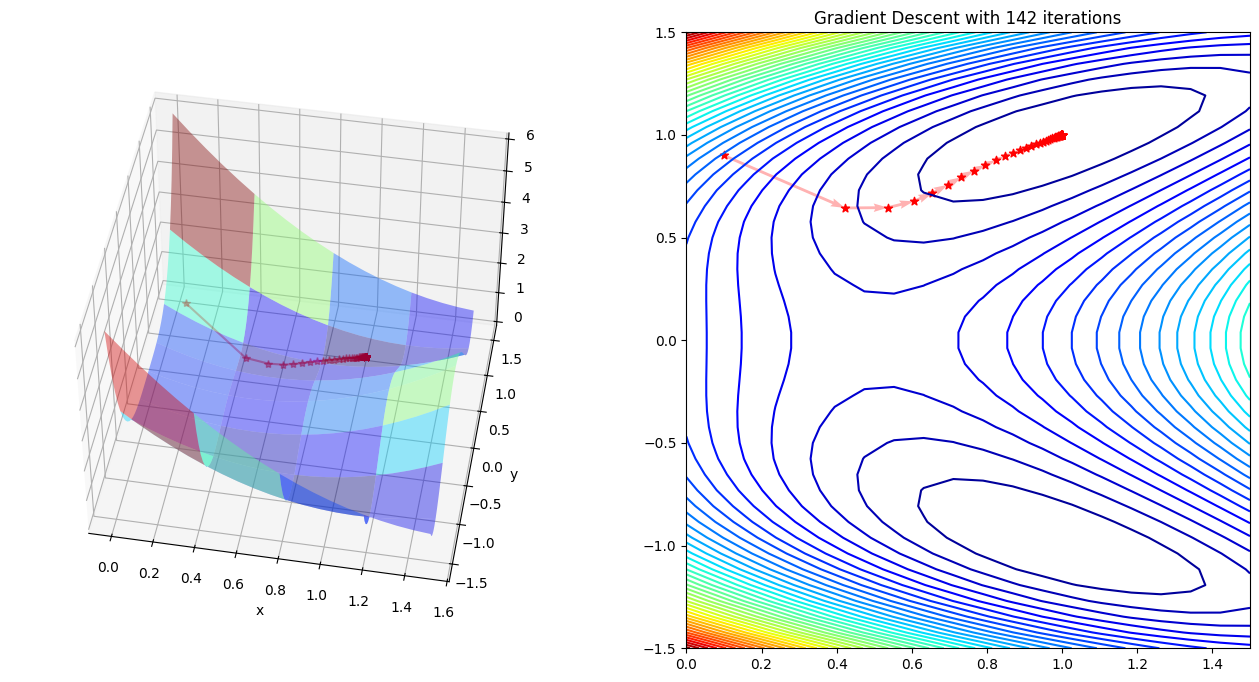

In [ ]:
plot_trace_GD(iter_x, iter_y)

### Question 7

**Algorithme de descente par gradient à pas optimal :**

Même principe que le pas constant, mais à chaque itération le pas $\mu_k$ est choisi pour minimiser $f$ le long de la direction de descente :
$$\mu_k = \arg\min_{\mu > 0} f(x_k - \mu \nabla f(x_k))$$
$$x_{k+1} = x_k - \mu_k \nabla f(x_k)$$
La convergence est assurée et généralement plus rapide, mais chaque itération est plus coûteuse (recherche du minimum en 1D).

### Question 8

In [ ]:
def gss(f, a, b, tol=1e-10):
    phi = (np.sqrt(5) + 1) / 2
    d = b - (b - a) / phi
    c = a + (b - a) / phi
    while abs(d - c) > tol:
        if f(d) < f(c):
            b = c
        else:
            a = d
        d = b - (b - a) / phi
        c = a + (b - a) / phi
    return (a + b) / 2

def gradient_descent_optimal(J, J_grad, x_init, max_iterations, epsilon=1e-10):
    x = np.array(x_init, dtype=float)
    iter_x = [x[0]]
    iter_y = [x[1]]
    iter_count = 0
    for i in range(max_iterations):
        grad = J_grad(x)
        if np.linalg.norm(grad) < epsilon:
            break
        phi_mu = lambda mu: J(x - mu * grad, 1)
        mu_opt = gss(phi_mu, 0, 1)
        x = x - mu_opt * grad
        iter_x.append(x[0])
        iter_y.append(x[1])
        iter_count += 1
    return x, np.array(iter_x), np.array(iter_y), iter_count

In [ ]:
x_init = np.array([0.1, 0.9])
max_iterations = 10000
x_opt, iter_x_opt, iter_y_opt, iter_count_opt = gradient_descent_optimal(
    rosenbrock, rosenbrock_grad, x_init, max_iterations)
print(f'Solution (pas optimal) : {x_opt}')
print(f"Nombre d\'itérations : {iter_count_opt}")

Solution (pas optimal) : [1. 1.]
Nombre d'itérations : 43


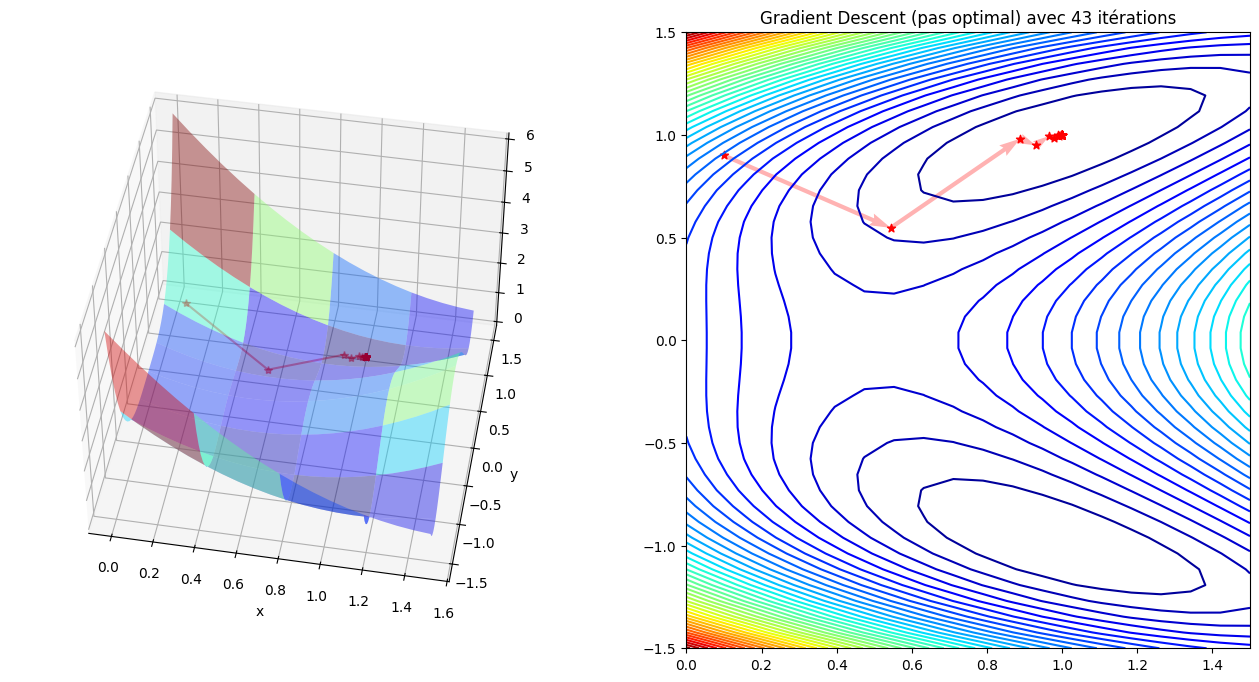

In [ ]:
def plot_trace_GD_opt(iter_x, iter_y, iter_count):
    X = np.linspace(0, 1.5, 20)
    Y = np.linspace(-1.5, 1.5, 40)
    X, Y = np.meshgrid(X, Y)
    Z = rosenbrock([X, Y], 1)
    anglesx = iter_x[1:] - iter_x[:-1]
    anglesy = iter_y[1:] - iter_y[:-1]
    fig = plt.figure(figsize=(16, 8))
    ax = fig.add_subplot(1, 2, 1, projection='3d')
    ax.plot_surface(X, Y, Z, rstride=5, cstride=5, cmap='jet', alpha=.4, edgecolor='none')
    ax.plot(iter_x, iter_y, rosenbrock([iter_x, iter_y], 1), color='r', marker='*', alpha=.4)
    ax.view_init(45, 280)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax = fig.add_subplot(1, 2, 2)
    ax.contour(X, Y, Z, 50, cmap='jet')
    ax.scatter(iter_x, iter_y, color='r', marker='*')
    ax.quiver(iter_x[:-1], iter_y[:-1], anglesx, anglesy,
              scale_units='xy', angles='xy', scale=1, color='r', alpha=.3)
    ax.set_title(f'Gradient Descent (pas optimal) avec {iter_count} itérations')
    plt.show()

plot_trace_GD_opt(iter_x_opt, iter_y_opt, iter_count_opt)

### Question 9

On compare l'erreur quadratique $\|x_k - x^*\|_2$ à chaque itération pour les deux méthodes (même point de départ), en échelle linéaire puis logarithmique.

In [ ]:
x_init = np.array([0.1, 0.9])
x_star = np.array([1.0, 1.0])

# Pas constant (alpha=0.1, même que Q6)
x_c, ix_c, iy_c, ic_c = gradient_descent(rosenbrock_grad, x_init, 0.1, 1000)
err_const = [np.linalg.norm(np.array([ix_c[k], iy_c[k]]) - x_star) for k in range(len(ix_c))]

# Pas optimal
x_o, ix_o, iy_o, ic_o = gradient_descent_optimal(rosenbrock, rosenbrock_grad, x_init, 1000)
err_opt = [np.linalg.norm(np.array([ix_o[k], iy_o[k]]) - x_star) for k in range(len(ix_o))]

print(f'Pas constant (alpha=0.1) : {ic_c} itérations, solution = {x_c}')
print(f'Pas optimal             : {ic_o} itérations, solution = {x_o}')

Pas constant (alpha=0.1) : 142 itérations, solution = [1. 1.]
Pas optimal             : 43 itérations, solution = [1. 1.]


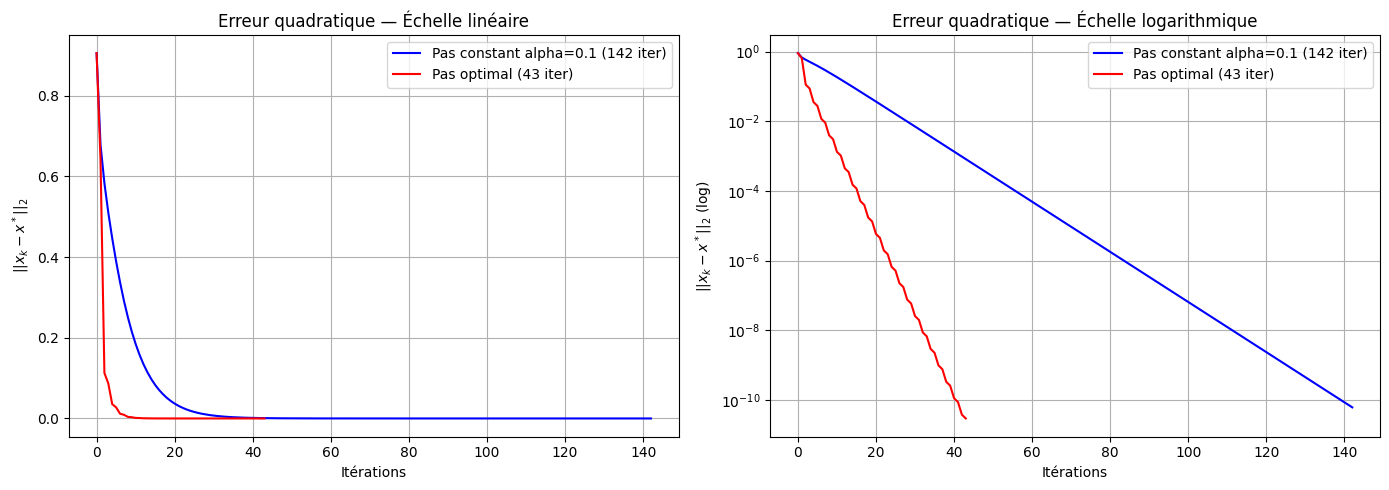

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Échelle linéaire
axes[0].plot(range(len(err_const)), err_const, 'b-', label=f'Pas constant alpha=0.1 ({ic_c} iter)')
axes[0].plot(range(len(err_opt)), err_opt, 'r-', label=f'Pas optimal ({ic_o} iter)')
axes[0].set_xlabel('Itérations')
axes[0].set_ylabel('$||x_k - x^*||_2$')
axes[0].set_title('Erreur quadratique — Échelle linéaire')
axes[0].legend()
axes[0].grid(True)

# Échelle logarithmique
axes[1].semilogy(range(len(err_const)), err_const, 'b-', label=f'Pas constant alpha=0.1 ({ic_c} iter)')
axes[1].semilogy(range(len(err_opt)), err_opt, 'r-', label=f'Pas optimal ({ic_o} iter)')
axes[1].set_xlabel('Itérations')
axes[1].set_ylabel('$||x_k - x^*||_2$ (log)')
axes[1].set_title('Erreur quadratique — Échelle logarithmique')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Question 10

La méthode à **pas optimal** converge nettement plus vite que la méthode à **pas constant**. En échelle logarithmique, on observe que l'erreur du pas optimal décroît de manière quasi-linéaire (convergence linéaire rapide), tandis que le pas constant nécessite beaucoup plus d'itérations pour atteindre la même précision. Cela s'explique par le fait que le pas optimal adapte $\mu_k$ à chaque itération pour maximiser la descente, alors que le pas constant peut être trop grand (oscillations) ou trop petit (convergence lente).
